# Seed basin of attraction — debug notebook

This notebook is **only for debugging seed basins of attraction** of the 2D Newton solver.
Goal: answer *"Which seed families converge to the sphaleron root, and which do not?"*

We probe basins using **distance metrics** (to known roots) and **diagnostics** (e.g. τ-dependence, slicewise energies).
Run from the directory that contains `Bubble_finder` (e.g. `BubbleX` or project root).

## 1. Imports and potential (copied from Final_Bubble_2D.ipynb)

Exact copy: project path, imports, potential/model/parameter setup, then solver/grid construction.

In [1]:
# ============================================================================
# Project path and configuration (copied from Final_Bubble_2D.ipynb)
# ============================================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Model parameters (same potential as in the 4D bounce notebook)
PHI0 = 1.999   # field value near the center of the bounce
V1 = 1.0       # false vacuum
V2 = 2.0       # true vacuum
OMEGA = 0.85    # chemical potential ω (can be changed)

print(f"Project root: {PROJECT_ROOT}")
print(f"Potential: false vacuum at φ={V1}, true vacuum at φ={V2}")
print(f"φ0 = {PHI0},  ω = {OMEGA}")

Project root: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX
Potential: false vacuum at φ=1.0, true vacuum at φ=2.0
φ0 = 1.999,  ω = 0.85


In [2]:
# ============================================================================
# Imports (copied from Final_Bubble_2D.ipynb)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# LaTeX fonts for all plots
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

from Q_ball_finder.grid import build_grid, RadialTimeGrid

from Bubble_finder.potential_bubble import (
    V_phi, dV_dphi, d2V_dphi2, Omega_phi, dOmega_dphi, d2Omega_dphi2, vacua_of_Omega,
)
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, make_potential_from_V, solve_rho0_for_omega
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.ansatz_bubble import (
    AnsatzParams, build_seed_bubble, tau_gate,
    make_q_ball_objects, make_bubble_profile_1d_from_solve_bounce, PotentialModel,
)
from Bubble_finder.branching import (
    slicewise_energies, slicewise_energies_at_tau,
    recenter_solution_in_tau, make_centered_tau_and_roll,
    find_bounce_from_sphaleron,
)
from Bubble_finder.observables_2d import homogeneous_energy_2d, homogeneous_E_M_2d
from Bubble_finder.observables_1d import Q_homogeneous_ball

# Potential U(ρ)=V(φ) for the 2D solver (requires PHI0, V1, V2 from previous cell)
U, dU, d2U = make_potential_from_V(V_phi, dV_dphi, d2V_dphi2, phi0=PHI0, v1=V1, v2=V2)

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

print("Imports and potential completed.")

Imports and potential completed.


In [3]:
# ============================================================================
# 1D bounce (for Lr and bubble profile) + 2D solver and grid (copied/simplified from Final_Bubble_2D)
# ============================================================================

# 1D bounce
RMAX = 10.0
r_bounce, phi_bounce, _, _, _ = solve_bounce(
    PHI0, V1, V2, OMEGA,
    d=3, r0=1e-6, rmax=RMAX, max_iter=150, verbose=False,
)
r_bounce = np.asarray(r_bounce, float)
phi_bounce = np.asarray(phi_bounce, float)
Lr_2d = float(r_bounce[-1]) if r_bounce is not None else 10.0

# 2D solver and grid (same logic as gated run in Final_Bubble_2D)
Nr_2d, Ntau_2d = 50, 50
beta_2d = 10.0
rho_false_2d, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)
rho0_2d = float(rho_false_2d)

settings_2d = Bubble2DSettings(
    Nr=Nr_2d, Ntau=Ntau_2d, Lr=Lr_2d, beta=beta_2d,
    omega_ref=OMEGA, rho0=rho0_2d, rho0_bracket=(V1 * 0.8, V2 + 0.2),
    newton_tol=1e-8, newton_max_iter=35, tau_bc="twisted",
)
solver = Bubble2DSolver(settings_2d, U, dU, d2U)
grid = solver.grid

print(f"Solver: Nr={solver.Nr}, Ntau={solver.Nt}, Lr={Lr_2d}, beta={beta_2d}")
print("solver and grid ready.")

[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
Solver: Nr=50, Ntau=50, Lr=3.7058442697396323, beta=10.0
solver and grid ready.


## 2. Reference solutions: banal + sphaleron

**(a)** Banal: homogeneous seed (y=0, ybar=0) → solve → `sol_banal`.

**(b)** Sphaleron: same procedure as in Final_Bubble_2D to get the sphaleron-like solution (gated 1D bubble → Newton → `sol_2d_g`). We store it as `sol_sph`.

**(c)** Packed vectors `x_banal`, `x_sph` are the two **known roots** used for classification.

In [4]:
# (a) Banal reference: homogeneous seed
x_hom = solver._zero_vec()
sol_banal = solver.solve(x_hom, verbose=False, verbose_success_block=False)

# (b) Sphaleron reference: gated 1D bubble → Newton (same as Final_Bubble_2D cell "Gated bubble")
r_grid = np.asarray(solver.grid.r).flatten()
tau_grid = np.asarray(solver.grid.tau).flatten()
T_2d = beta_2d / 2.0
params_gated = AnsatzParams(eps=1.0, k=1, phase=0.0, amp=1.0, tau_gate_frac=0.25, tau_gate_center_frac=1, r_window_frac=0.15)
phi_on_r = np.interp(r_grid, r_bounce, phi_bounce, left=phi_bounce[0], right=phi_bounce[-1])
y_slice = r_grid * (phi_on_r - solver.rho0)
g_tau = tau_gate(tau_grid, T_2d, params_gated.tau_gate_frac, center_frac=params_gated.tau_gate_center_frac)
y_gated = params_gated.amp * np.outer(y_slice, g_tau).astype(complex)
ybar_gated = y_gated.copy()
x0_gated = solver.pack(y_gated, ybar_gated)
sol_sph = solver.solve(x0_gated, verbose=False, verbose_success_block=False)

# (c) Packed reference vectors
x_banal = solver.pack(sol_banal.y, sol_banal.ybar)
x_sph = solver.pack(sol_sph.y, sol_sph.ybar)

print("Reference roots: x_banal (homogeneous), x_sph (sphaleron-like).")
print(f"||x_sph - x_banal|| = {np.linalg.norm(np.asarray(x_sph).ravel() - np.asarray(x_banal).ravel()):.6e}")

Reference roots: x_banal (homogeneous), x_sph (sphaleron-like).
||x_sph - x_banal|| = 3.861553e+00


## 3. Diagnostics helpers

- **pack(sol)** → packed vector x (via solver.pack).
- **xdist(xa, xb)** → Euclidean distance in packed space.
- **classify_solution(sol)** → dict with `dist_to_sph`, `dist_to_banal`, `amp_tau` (ρ variation at r_probe vs τ), `dE_static` (slicewise energies), `notes`.
- **is_same_root(dist, tol)** → True if distance &lt; tol.
- **recenter_and_centered_tau_plot(sol)** → recenter in τ, then centered τ axis and rolled arrays for seam-safe plotting.

In [5]:
def pack(sol):
    """Pack solution (y, ybar) into vector x."""
    return solver.pack(sol.y, sol.ybar)

def xdist(xa, xb):
    """Euclidean norm in packed space."""
    a = np.asarray(xa, dtype=float).ravel()
    b = np.asarray(xb, dtype=float).ravel()
    return float(np.linalg.norm(a - b))

def classify_solution(sol, r_probe_index=1):
    """Return dict: dist_to_sph, dist_to_banal, amp_tau, dE_static, notes."""
    x = np.asarray(pack(sol), dtype=float).ravel()
    dist_to_sph = xdist(x, x_sph)
    dist_to_banal = xdist(x, x_banal)
    rho = solver.rho_map(sol.y, sol.ybar)
    Nt = rho.shape[1]
    j = int(np.clip(r_probe_index, 0, rho.shape[0] - 1))
    rho_j = np.asarray(rho[j, :]).flatten()
    i_mid = Nt // 2
    amp_tau = float(np.max(np.abs(rho_j - rho_j[i_mid])))
    tau_sorted, E_static, E_full = slicewise_energies(solver, sol)
    dE_static = float(np.max(E_static) - np.min(E_static))
    notes = []
    if amp_tau > 1e-3:
        notes.append("tau-dependent")
    out = {
        "dist_to_sph": dist_to_sph,
        "dist_to_banal": dist_to_banal,
        "amp_tau": amp_tau,
        "dE_static": dE_static,
        "notes": "; ".join(notes) if notes else "",
    }
    return out

def is_same_root(dist, tol=1e-6):
    return float(dist) < tol


def reorder_and_reflect_full_tau(solver, tau_plot, y2, ybar2, roll_info):
    """Reorder slices so that data at index i corresponds to tau_plot[i]; reflect for τ>0 (y↔ybar).
    After the roll, rolled index i holds the slice at physical tau = solver.grid.tau[(i - shift)%Nt].
    We reorder so that position i has the slice that belongs at tau_plot[i]; for τ>0 use reflected slice."""
    shift = roll_info["shift"]
    tau_solver = np.asarray(solver.grid.tau).flatten()
    Nt = len(tau_solver)
    physical_tau = np.array([tau_solver[(i - shift) % Nt] for i in range(Nt)])
    y2_new = np.zeros_like(y2)
    ybar2_new = np.zeros_like(ybar2)
    for i in range(Nt):
        if tau_plot[i] <= 0:
            j = int(np.argmin(np.abs(physical_tau - tau_plot[i])))
            y2_new[:, i] = y2[:, j]
            ybar2_new[:, i] = ybar2[:, j]
        else:
            j = int(np.argmin(np.abs(physical_tau - (-tau_plot[i]))))
            y2_new[:, i] = ybar2[:, j]
            ybar2_new[:, i] = y2[:, j]
    return y2_new, ybar2_new


def recenter_and_centered_tau_plot(sol):
    """Recenter solution in τ, build centered tau axis, then reorder + reflect for full [-β/2, β/2]."""
    y_rc, ybar_rc, rc_info = recenter_solution_in_tau(solver, sol, tau_turn_target=0.0, method="rho_peak", r_probe_index=1)
    tau_plot, y2, ybar2, roll_info = make_centered_tau_and_roll(solver, y_rc, ybar_rc, tau_center=0.0)
    y2, ybar2 = reorder_and_reflect_full_tau(solver, tau_plot, y2, ybar2, roll_info)
    return tau_plot, y2, ybar2, {**rc_info, **roll_info}

print("Diagnostics helpers defined.")

Diagnostics helpers defined.


### Verifica ricostruzione: plot dello sphaleron su [-β/2, β/2]

Plot della soluzione di riferimento (sphaleron) appena trovata, per verificare che la ricostruzione con riflessione su tutto l'intervallo τ sia corretta.

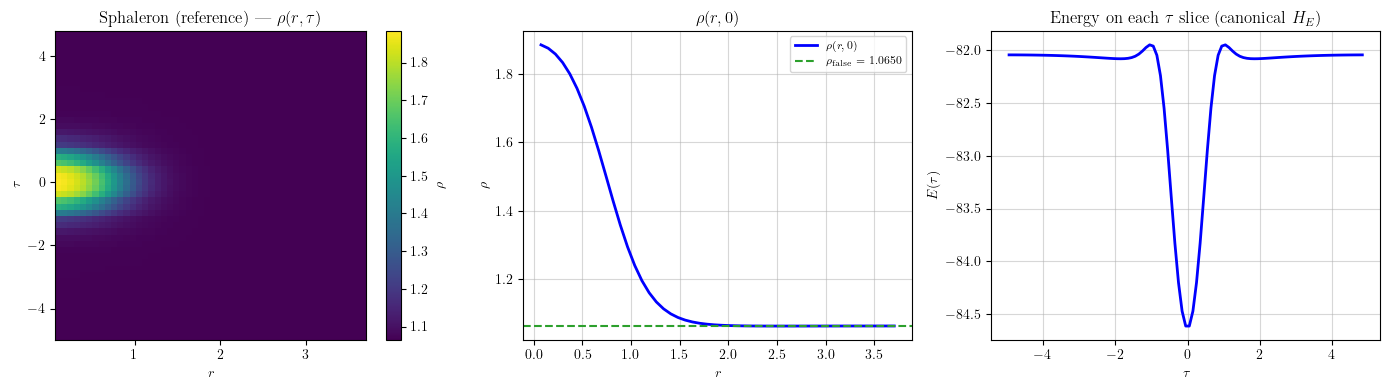

[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01

--- Sphaleron (reference): full diagnostics ---
  Homogeneous reference: ω = OMEGA = 0.850000
  Grid: β = 9.8, Lr = 3.7058442697396323, Nr = 50, Nτ = 50
  Volume V = (4/3)π Lr³ = 213.181790
  η₀* = 0.000000

  Solution (sphaleron):
    Q(τ=0) = 206.427472,   E(τ=0) = -84.573372
    ρ_Q = Q/V = 0.968317,   ρ_E = E/V = -0.396719

  Reference homogeneous at ω = OMEGA (same V):
    Q_hom = 205.541665,   E_hom = -80.622836
    ρ_Q,hom = 0.964161,   ρ_E,hom = -0.378188

  Ratios:  Q/Q_hom = 1.004310,  E/E_hom = 1.049000
  Density ratios:  ρ_Q/ρ_Q,hom = 1.004310,  ρ_E/ρ_E,hom = 1.049000
  Difference:  E - E_hom (H_E) = -3.950536
  E_M - E_M_hom(OMEGA) = 3.950536
  F_ω (sph) = -90.889979,  F_ω,hom = -94.087579,  F_ω - F_ω,hom = 3.197600
---
Sphaleron (reference): {'dist_to_sph': 0.

In [6]:
# Plot sphaleron (reference) per verificare la ricostruzione [-β/2, β/2]
# Tre pannelli: (1) ρ(r,τ) heatmap, (2) ρ(r,0) slice, (3) E(τ) per slice (canonical H_E)
tau_plot_sph, y2_sph, ybar2_sph, _ = recenter_and_centered_tau_plot(sol_sph)
r = np.asarray(solver.grid.r).flatten()
rho_sph = solver.rho_map(y2_sph, ybar2_sph)
rho_false_sph = float(solver.rho0)
fig_sph, axes_sph = plt.subplots(1, 3, figsize=(14, 4))
extent = (r[0], r[-1], tau_plot_sph[0], tau_plot_sph[-1])
im = axes_sph[0].imshow(rho_sph.T, origin="lower", aspect="auto", extent=extent)
axes_sph[0].set_xlabel(r"$r$")
axes_sph[0].set_ylabel(r"$\tau$")
axes_sph[0].set_title(r"Sphaleron (reference) — $\rho(r,\tau)$")
plt.colorbar(im, ax=axes_sph[0], label=r"$\rho$")
# Pannello 2: ρ(r, 0) come in Final_Bubble_2D
idx_tau0 = int(np.argmin(np.abs(tau_plot_sph - 0.0)))
rho_at_tau0 = rho_sph[:, idx_tau0]
axes_sph[1].plot(r, rho_at_tau0, "b-", lw=2, label=r"$\rho(r,0)$")
axes_sph[1].axhline(rho_false_sph, color="C2", ls="--", lw=1.5, label=rf"$\rho_{{\mathrm{{false}}}}$ = {rho_false_sph:.4f}")
axes_sph[1].set_xlabel(r"$r$")
axes_sph[1].set_ylabel(r"$\rho$")
axes_sph[1].set_title(r"$\rho(r,0)$")
axes_sph[1].legend(loc="best", fontsize=8)
axes_sph[1].grid(True, alpha=0.5)
# Pannello 3: E(τ) su ogni slice (canonical H_E). Soluzione ORIGINALE (y,ybar): slicewise su dati riordinati darebbe φ errato (solver.phi usa grid.tau).
_, E_tau_sph = solver.compute_energy(sol_sph.y, sol_sph.ybar, return_profile=True)
tau_grid = np.asarray(solver.grid.tau).flatten()
# Sphaleron: E(τ)=E(-τ); estendiamo a [-β/2, β/2] per riflessione
tau_pos = -np.flip(tau_grid)[1:]
E_pos = np.flip(E_tau_sph)[1:]
tau_full = np.concatenate([tau_grid, tau_pos])
E_full = np.concatenate([E_tau_sph, E_pos])
sidx = np.argsort(tau_full)
tau_full, E_full = tau_full[sidx], E_full[sidx]
axes_sph[2].plot(tau_full, E_full, "b-", lw=2)
axes_sph[2].set_xlabel(r"$\tau$")
axes_sph[2].set_ylabel(r"$E(\tau)$")
axes_sph[2].set_title(r"Energy on each $\tau$ slice (canonical $H_E$)")
axes_sph[2].grid(True, alpha=0.5)
plt.tight_layout()
fig_sph.savefig(FIGURES_DIR / "sphaleron_reconstruction_check.png", dpi=150, bbox_inches="tight")
plt.show()

# Diagnostica completa sphaleron (stesso formato di OTHER_ROOT / Final_Bubble_2D)
r_sph = np.asarray(solver.grid.r).flatten()
Lr_sph = float(r_sph[-1])
V_sph = (4.0 / 3.0) * np.pi * Lr_sph**3
beta_sph = float(getattr(solver.grid, "beta", 2.0 * np.abs(np.ptp(np.asarray(solver.grid.tau).flatten()))))
Nr_sph = len(r_sph)
Ntau_sph = len(np.asarray(solver.grid.tau).flatten())
rho_false_sph_ref, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)
Q_hom_sph = float(Q_homogeneous_ball(OMEGA, rho_false_sph_ref, Lr_sph))
E_hom_sph = float(homogeneous_energy_2d(OMEGA, rho_false_sph_ref, Lr_sph, U))
Q_sph = float(sol_sph.Q_tau0.real)
E_sph = float(sol_sph.E_tau0)
rho_Q_hom_sph = Q_hom_sph / V_sph
rho_E_hom_sph = E_hom_sph / V_sph
rho_Q_sph = Q_sph / V_sph
rho_E_sph = E_sph / V_sph
eta_sph = getattr(solver, "eta0", None)
eta_str_sph = f"{eta_sph:.6f}" if eta_sph is not None else "N/A"
print("\n--- Sphaleron (reference): full diagnostics ---")
print(f"  Homogeneous reference: ω = OMEGA = {OMEGA:.6f}")
print(f"  Grid: β = {beta_sph}, Lr = {Lr_sph}, Nr = {Nr_sph}, Nτ = {Ntau_sph}")
print(f"  Volume V = (4/3)π Lr³ = {V_sph:.6f}")
print(f"  η₀* = {eta_str_sph}")
print("")
print("  Solution (sphaleron):")
print(f"    Q(τ=0) = {Q_sph:.6f},   E(τ=0) = {E_sph:.6f}")
print(f"    ρ_Q = Q/V = {rho_Q_sph:.6f},   ρ_E = E/V = {rho_E_sph:.6f}")
print("")
print("  Reference homogeneous at ω = OMEGA (same V):")
print(f"    Q_hom = {Q_hom_sph:.6f},   E_hom = {E_hom_sph:.6f}")
print(f"    ρ_Q,hom = {rho_Q_hom_sph:.6f},   ρ_E,hom = {rho_E_hom_sph:.6f}")
print("")
print(f"  Ratios:  Q/Q_hom = {Q_sph/Q_hom_sph:.6f},  E/E_hom = {E_sph/E_hom_sph:.6f}")
print(f"  Density ratios:  ρ_Q/ρ_Q,hom = {rho_Q_sph/rho_Q_hom_sph:.6f},  ρ_E/ρ_E,hom = {rho_E_sph/rho_E_hom_sph:.6f}")
print(f"  Difference:  E - E_hom (H_E) = {E_sph - E_hom_sph:.6f}")
obs_sph = getattr(sol_sph, "observables_ghost", None) or {}
E_M_hom_sph = float(homogeneous_E_M_2d(OMEGA, rho_false_sph_ref, Lr_sph, U))
if "E_M" in obs_sph:
    print(f"  E_M - E_M_hom(OMEGA) = {obs_sph['E_M'] - E_M_hom_sph:.6f}")
if "F_omega" in obs_sph:
    F_sph = obs_sph["F_omega"]
    F_hom_sph = E_M_hom_sph - OMEGA * Q_hom_sph
    print(f"  F_ω (sph) = {F_sph:.6f},  F_ω,hom = {F_hom_sph:.6f},  F_ω - F_ω,hom = {F_sph - F_hom_sph:.6f}")
print("---")
print("Sphaleron (reference):", classify_solution(sol_sph))

## 4. Seed families to test

- **A) O(3) 1D bubble gated in τ** via `build_seed_bubble`: scan tau_gate_center_frac, tau_gate_frac, amp, eps. The library uses a background τ-ramp (rho_ref → rho_tilde); no toggle in the API — change in library if needed.
- **B) Tau–Fourier seeds**: manual g(τ) = Σ a_n cos + b_n sin, δρ from 1D or sphaleron slice; scan amplitude A and a few random seeds.
- **C) Negative-mode pinned** from `find_bounce_from_sphaleron(..., release_after_pin=True/False)`; treat produced solution(s) as seeds and classify.
- **D) Deliberately sphaleron-attracting**: sphaleron + small random perturbation (sanity check).

In [8]:
grid2d, fields, potential_model, _, _ = make_q_ball_objects(solver)
bubble_profile_1d = make_bubble_profile_1d_from_solve_bounce(solve_bounce, PHI0, V1, V2)
omega_ref = float(OMEGA)
omega_tilde = float(OMEGA)

def seed_family_A():
    """O(3) 1D bubble gated in τ (build_seed_bubble)."""
    out = []
    for tau_gate_center_frac in [0.5, 1.0]:
        for tau_gate_frac in [0.05, 0.1, 0.2]:
            for amp in [0.5, 1.0, 2.0]:
                for eps in [0.01, 0.02, 0.05]:
                    params = AnsatzParams(
                        eps=eps, k=1, phase=0.0, amp=amp,
                        tau_gate_frac=tau_gate_frac,
                        tau_gate_center_frac=tau_gate_center_frac,
                        r_window_frac=0.15,
                    )
                    try:
                        x0, meta = build_seed_bubble(
                            grid=grid2d, fields=fields, potential=potential_model,
                            omega_ref=omega_ref, omega_tilde=omega_tilde,
                            bubble_profile_1d=bubble_profile_1d, params=params,
                        )
                        out.append({"name": "O3_gated", "x0": x0, "meta": {**meta, "tau_gate_center_frac": tau_gate_center_frac, "tau_gate_frac": tau_gate_frac, "amp": amp, "eps": eps}})
                    except Exception as e:
                        pass
    return out

def seed_family_B(n_trials=5, amplitudes=(0.2, 0.5, 1.0, 2.0)):
    """Tau–Fourier seeds: g(τ) = sum_n (a_n cos + b_n sin), zero mean; δρ from sphaleron slice."""
    r = np.asarray(solver.grid.r).flatten()
    tau = np.asarray(solver.grid.tau).flatten()
    T = float(np.ptp(tau)) / 2.0 if np.ptp(tau) > 0 else 1.0
    # δρ from sphaleron at one τ slice (e.g. middle)
    rho_sph = solver.rho_map(sol_sph.y, sol_sph.ybar)
    ir = min(1, rho_sph.shape[0] - 1)
    delta_rho_r = np.asarray(rho_sph[:, tau.size // 2]).flatten() - solver.rho0
    out = []
    for A in amplitudes:
        for trial in range(n_trials):
            np.random.seed(42 + trial + int(A * 100))
            a1, a2, a3 = np.random.randn(3)
            b1, b2, b3 = np.random.randn(3)
            n = np.array([1, 2, 3], dtype=float)
            g_tau = sum(a * np.cos(2 * np.pi * n * tau / T) + b * np.sin(2 * np.pi * n * tau / T) for a, b, n in zip([a1,a2,a3], [b1,b2,b3], n))
            g_tau = np.asarray(g_tau).flatten()
            g_tau = g_tau - np.mean(g_tau)
            nrm = np.sqrt(np.mean(g_tau**2)) or 1e-10
            g_tau = A * g_tau / nrm
            y_2d = np.outer(r * delta_rho_r, g_tau).astype(complex)
            ybar_2d = y_2d.copy()
            x0 = solver.pack(y_2d, ybar_2d)
            out.append({"name": "TauFourier", "x0": x0, "meta": {"A": A, "trial": trial}})
    return out

def seed_family_C():
    """Negative-mode pinned: find_bounce_from_sphaleron; use produced solutions as seeds."""
    out = []
    for release in [True, False]:
        best_bounce, diag = find_bounce_from_sphaleron(
            solver, sol_sph,
            eps_list=np.array([1e-3, 5e-3, 1e-2]),
            max_tries=20, release_after_pin=release, verbose=False,
        )
        for rec in diag.get("table", []):
            if rec.get("sol") is not None:
                sol = rec["sol"]
                x0 = solver.pack(sol.y, sol.ybar)
                out.append({"name": "NegMode_pinned", "x0": x0, "meta": {"release_after_pin": release, "eps": rec.get("eps")}})
        if best_bounce is not None:
            x0 = solver.pack(best_bounce.y, best_bounce.ybar)
            out.append({"name": "NegMode_best", "x0": x0, "meta": {"release_after_pin": release}})
    return out

def seed_family_D(n_pert=5, scale=1e-4):
    """Sphaleron + small random perturbation (sanity: should converge back to sphaleron)."""
    x = np.asarray(x_sph).ravel()
    out = []
    for i in range(n_pert):
        np.random.seed(100 + i)
        dx = scale * np.random.randn(x.size)
        x0 = x + dx
        out.append({"name": "Sph_pert", "x0": x0, "meta": {"scale": scale, "i": i}})
    return out

# Build list of seed generators (each returns list of {"name", "x0", "meta"})
all_seeds = []
all_seeds.extend(seed_family_A())
all_seeds.extend(seed_family_B(n_trials=3, amplitudes=(0.2, 0.5, 1.0)))
all_seeds.extend(seed_family_C())
all_seeds.extend(seed_family_D(n_pert=3, scale=1e-4))
print(f"Total seeds to test: {len(all_seeds)}")

Total seeds to test: 18


## 5. Batch run: solve from each seed and classify

For each seed: try `solver.solve(x0)`; if converged, run `classify_solution(sol)`. Store rows with name, meta, converged, dist_sph, dist_banal, amp_tau, dE_static, **classification label**: SPHALERON / BANAL / OTHER_ROOT / DIVERGED. Results in a pandas DataFrame, sorted by label then dist_sph.

In [9]:
from Bubble_finder.bounce2d import NewtonConvergenceError

TOL_ROOT = 1e-6
rows = []
solutions_by_label = {"SPHALERON": [], "BANAL": [], "OTHER_ROOT": [], "DIVERGED": []}

for i, seed in enumerate(all_seeds):
    name = seed["name"]
    x0 = seed["x0"]
    meta = seed.get("meta", {})
    row = {"name": name, "meta": str(meta)[:80], **{k: meta.get(k) for k in ["tau_gate_center_frac", "tau_gate_frac", "amp", "eps", "A", "release_after_pin", "scale"] if k in meta}}
    try:
        sol = solver.solve(x0, verbose=True, verbose_success_block=False)
        conv = getattr(sol, "success", True)
    except (NewtonConvergenceError, RuntimeError, Exception):
        sol = None
        conv = False
    row["converged"] = conv
    if not conv or sol is None:
        row["label"] = "DIVERGED"
        row["dist_sph"] = row["dist_banal"] = row["amp_tau"] = row["dE_static"] = np.nan
        solutions_by_label["DIVERGED"].append(None)
    else:
        cl = classify_solution(sol)
        row["dist_sph"] = cl["dist_to_sph"]
        row["dist_banal"] = cl["dist_to_banal"]
        row["amp_tau"] = cl["amp_tau"]
        row["dE_static"] = cl["dE_static"]
        if is_same_root(cl["dist_to_sph"], TOL_ROOT):
            row["label"] = "SPHALERON"
            solutions_by_label["SPHALERON"].append(sol)
        elif is_same_root(cl["dist_to_banal"], TOL_ROOT):
            row["label"] = "BANAL"
            solutions_by_label["BANAL"].append(sol)
        else:
            row["label"] = "OTHER_ROOT"
            solutions_by_label["OTHER_ROOT"].append(sol)
    rows.append(row)

df = pd.DataFrame(rows)
df = df.sort_values(by=["label", "dist_sph"]).reset_index(drop=True)
display(df)

[Newton-explicit] iter=01, ||F||=2.045e+00, rhoQ=9.640674e-01, rhoE=-3.780296e-01, rho_Q/rho_Q_ref=0.9999, rho_E/rho_E_ref=0.9996
[Newton-explicit] iter=02, ||F||=4.257e-03, rhoQ=9.641601e-01, rhoE=-3.781872e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000
[Newton-explicit] iter=03, ||F||=1.104e-07, rhoQ=9.641605e-01, rhoE=-3.781878e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000
[Newton-explicit] iter=04, ||F||=8.498e-13, rhoQ=9.641605e-01, rhoE=-3.781878e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000
[Newton-explicit] iter=01, ||F||=1.908e+00, rhoQ=9.641017e-01, rhoE=-3.780879e-01, rho_Q/rho_Q_ref=0.9999, rho_E/rho_E_ref=0.9997
[Newton-explicit] iter=02, ||F||=4.155e-03, rhoQ=9.641601e-01, rhoE=-3.781872e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000
[Newton-explicit] iter=03, ||F||=1.001e-07, rhoQ=9.641605e-01, rhoE=-3.781878e-01, rho_Q/rho_Q_ref=1.0000, rho_E/rho_E_ref=1.0000
[Newton-explicit] iter=04, ||F||=8.707e-13, rhoQ=9.641605e-01, rhoE=-3.781878e-01, rho_Q/r

,name,meta,A,converged,dist_sph,dist_banal,amp_tau,dE_static,label,eps,release_after_pin,scale
0,TauFourier,"{'A': 0.2, 'trial': 1}",0.2,True,7.749275e+00,1.652292e-14,2.220446e-16,1.136868e-13,BANAL,NaN,NaN,NaN
1,TauFourier,"{'A': 0.2, 'trial': 2}",0.2,True,7.749275e+00,1.576641e-14,2.220446e-16,1.421085e-13,BANAL,NaN,NaN,NaN
2,TauFourier,"{'A': 0.2, 'trial': 0}",0.2,True,7.749275e+00,1.652693e-14,2.220446e-16,1.278977e-13,BANAL,NaN,NaN,NaN
3,TauFourier,"{'A': 0.5, 'trial': 1}",0.5,True,7.749275e+00,1.995458e-14,1.554312e-15,1.421085e-13,BANAL,NaN,NaN,NaN
4,TauFourier,"{'A': 0.5, 'trial': 0}",0.5,True,7.749275e+00,1.754997e-14,2.220446e-16,8.526513e-14,BANAL,NaN,NaN,NaN
5,TauFourier,"{'A': 0.5, 'trial': 2}",0.5,True,7.749275e+00,1.959253e-14,1.554312e-15,1.278977e-13,BANAL,NaN,NaN,NaN
6,TauFourier,"{'A': 1.0, 'trial': 1}",1.0,True,7.749275e+00,2.083985e-12,1.931788e-13,6.394885e-13,BANAL,NaN,NaN,NaN
7,TauFourier,"{'A': 1.0, 'trial': 0}",1.0,True,7.749275e+00,1.839452e-12,1.454392e-13,7.958079e-13,BANAL,NaN,NaN,NaN
8,TauFourier,"{'A': 1.0, 'trial': 2}",1.0,True,7.749275e+00,2.547329e-12,2.808864e-13,1.222134e-12,BANAL,NaN,NaN,NaN
9,NegMode_best,{'release_after_pin': True},NaN,False,NaN,NaN,NaN,NaN,DIVERGED,NaN,True,NaN


## 6. Plots for representative cases

Pick one SPHALERON, one BANAL, up to two OTHER_ROOT. For each: heatmap ρ(r,τ) (centered τ, seam-safe), E_static(τ) and E_full(τ), and key diagnostics.

SPHALERON {'dist_to_sph': 4.5622767254775744e-08, 'dist_to_banal': 7.749274718247651, 'amp_tau': 0.8153923765859783, 'dE_static': 6.524648131067053, 'notes': 'tau-dependent'}
BANAL {'dist_to_sph': 7.749274718247655, 'dist_to_banal': 1.6526934661081282e-14, 'amp_tau': 2.220446049250313e-16, 'dE_static': 1.2789769243681803e-13, 'notes': ''}
OTHER_ROOT {'dist_to_sph': 0.010363371494363864, 'dist_to_banal': 7.749281666279694, 'amp_tau': 0.8153923765872673, 'dE_static': 6.524648131070407, 'notes': 'tau-dependent'}
[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01

--- OTHER_ROOT: full diagnostics ---
  Homogeneous reference: ω = OMEGA = 0.850000
  Grid: β = 9.9, Lr = 3.7058442697396323, Nr = 100, Nτ = 100
  Volume V = (4/3)π Lr³ = 213.181790
  η₀* = 0.000000

  Solution (OTHER_ROOT from seed basin):
    Q(τ=0) = 206.420122,   E(

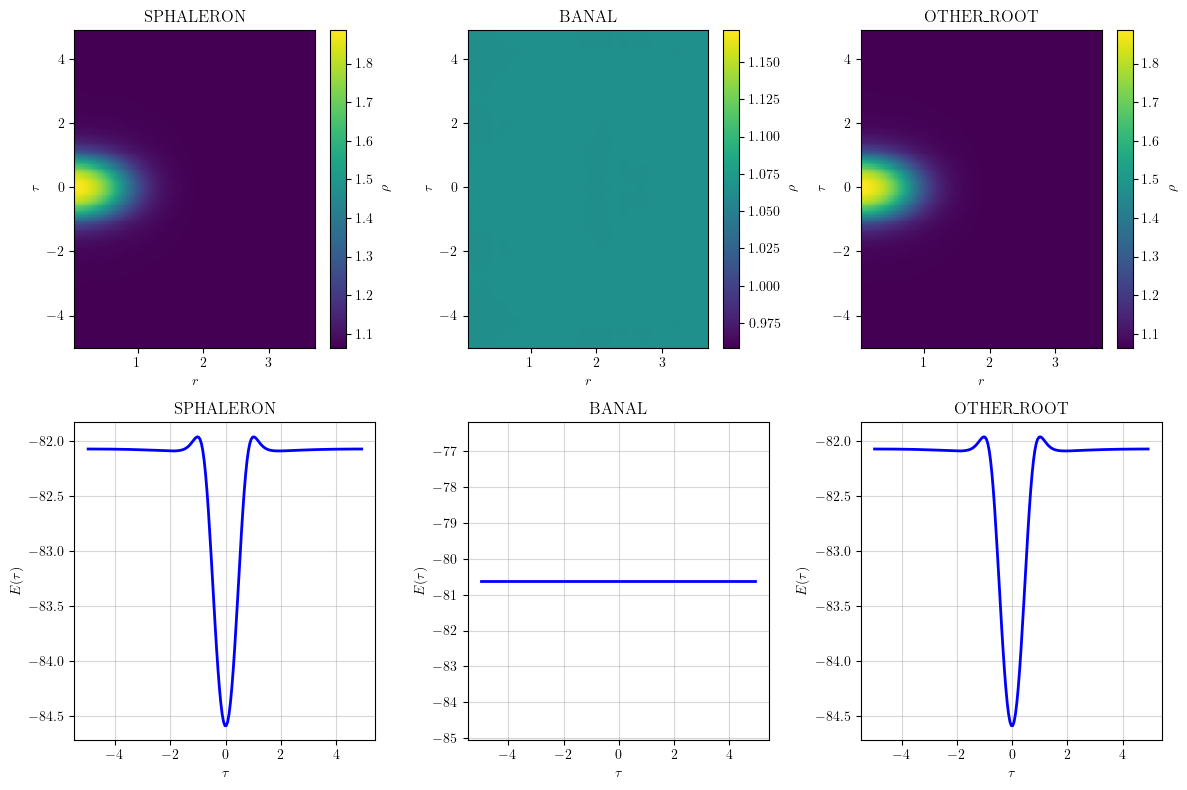

In [11]:
def plot_representative(sol, title, ax_heat, ax_E):
    tau_plot, y2, ybar2, _ = recenter_and_centered_tau_plot(sol)
    r = np.asarray(solver.grid.r).flatten()
    rho = solver.rho_map(y2, ybar2)
    extent = (r[0], r[-1], tau_plot[0], tau_plot[-1])
    im = ax_heat.imshow(rho.T, origin="lower", aspect="auto", extent=extent)
    ax_heat.set_xlabel(r"$r$")
    ax_heat.set_ylabel(r"$\tau$")
    ax_heat.set_title(title)
    plt.colorbar(im, ax=ax_heat, label=r"$\rho$")
    # E(\u03c4) come in diagnostica ricostruzione: soluzione originale + compute_energy + riflessione [-\u03b2/2, \u03b2/2]
    _, E_tau = solver.compute_energy(sol.y, sol.ybar, return_profile=True)
    tau_grid = np.asarray(solver.grid.tau).flatten()
    tau_pos = -np.flip(tau_grid)[1:]
    E_pos = np.flip(E_tau)[1:]
    tau_full = np.concatenate([tau_grid, tau_pos])
    E_full = np.concatenate([E_tau, E_pos])
    sidx = np.argsort(tau_full)
    tau_full, E_full = tau_full[sidx], E_full[sidx]
    ax_E.plot(tau_full, E_full, "b-", lw=2)
    ax_E.set_xlabel(r"$\tau$")
    ax_E.set_ylabel(r"$E(\tau)$")
    ax_E.set_title(title)
    ax_E.grid(True, alpha=0.5)

repr_sph = solutions_by_label["SPHALERON"][0] if solutions_by_label["SPHALERON"] else None
repr_banal = solutions_by_label["BANAL"][0] if solutions_by_label["BANAL"] else None
repr_other = solutions_by_label["OTHER_ROOT"][:2]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
ax_heat = [axes[0, 0], axes[0, 1], axes[0, 2]]
ax_E = [axes[1, 0], axes[1, 1], axes[1, 2]]
for idx, (sol, label) in enumerate([(repr_sph, "SPHALERON"), (repr_banal, "BANAL")]):
    if sol is not None:
        plot_representative(sol, label, ax_heat[idx], ax_E[idx])
        print(label, classify_solution(sol))
sol_other = None
for idx, sol in enumerate(repr_other):
    if sol is not None and idx < 1:
        sol_other = sol
        plot_representative(sol, "OTHER_ROOT", ax_heat[2], ax_E[2])
        print("OTHER_ROOT", classify_solution(sol))
        break
# Full diagnostics for OTHER_ROOT (same format as Final_Bubble_2D "Best bounce: full diagnostics")
if sol_other is not None:
    r_bb = np.asarray(solver.grid.r).flatten()
    Lr_bb = float(r_bb[-1])
    V_bb = (4.0 / 3.0) * np.pi * Lr_bb**3
    beta_bb = float(getattr(solver.grid, "beta", 2.0 * np.abs(np.ptp(np.asarray(solver.grid.tau).flatten()))))
    Nr_bb = len(r_bb)
    Ntau_bb = len(np.asarray(solver.grid.tau).flatten())
    rho_false_bb, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)
    Q_hom_bb = float(Q_homogeneous_ball(OMEGA, rho_false_bb, Lr_bb))
    E_hom_bb = float(homogeneous_energy_2d(OMEGA, rho_false_bb, Lr_bb, U))
    Q_sol = float(sol_other.Q_tau0.real)
    E_sol = float(sol_other.E_tau0)
    rho_Q_hom_bb = Q_hom_bb / V_bb
    rho_E_hom_bb = E_hom_bb / V_bb
    rho_Q_bb = Q_sol / V_bb
    rho_E_bb = E_sol / V_bb
    eta_bb = getattr(solver, "eta0", None)
    eta_str = f"{eta_bb:.6f}" if eta_bb is not None else "N/A"
    print("\n--- OTHER_ROOT: full diagnostics ---")
    print(f"  Homogeneous reference: ω = OMEGA = {OMEGA:.6f}")
    print(f"  Grid: β = {beta_bb}, Lr = {Lr_bb}, Nr = {Nr_bb}, Nτ = {Ntau_bb}")
    print(f"  Volume V = (4/3)π Lr³ = {V_bb:.6f}")
    print(f"  η₀* = {eta_str}")
    print("")
    print("  Solution (OTHER_ROOT from seed basin):")
    print(f"    Q(τ=0) = {Q_sol:.6f},   E(τ=0) = {E_sol:.6f}")
    print(f"    ρ_Q = Q/V = {rho_Q_bb:.6f},   ρ_E = E/V = {rho_E_bb:.6f}")
    print("")
    print("  Reference homogeneous at ω = OMEGA (φ = ρ_false(OMEGA), same V):")
    print(f"    Q_hom = {Q_hom_bb:.6f},   E_hom = {E_hom_bb:.6f}")
    print(f"    ρ_Q,hom = Q_hom/V = {rho_Q_hom_bb:.6f},   ρ_E,hom = E_hom/V = {rho_E_hom_bb:.6f}")
    print("")
    print(f"  Ratios (solution / homogeneous):  Q/Q_hom = {Q_sol/Q_hom_bb:.6f},  E/E_hom = {E_sol/E_hom_bb:.6f}")
    print(f"  Density ratios:  ρ_Q/ρ_Q,hom = {rho_Q_bb/rho_Q_hom_bb:.6f},  ρ_E/ρ_E,hom = {rho_E_bb/rho_E_hom_bb:.6f}")
    print(f"  Difference (densities):  ρ_Q - ρ_Q,hom = {rho_Q_bb - rho_Q_hom_bb:.6f},  ρ_E - ρ_E,hom = {rho_E_bb - rho_E_hom_bb:.6f}")
    print(f"  Difference:  E - E_hom (H_E) = {E_sol - E_hom_bb:.6f}")
    obs_bb = getattr(sol_other, "observables_ghost", None) or {}
    E_M_hom_bb = float(homogeneous_E_M_2d(OMEGA, rho_false_bb, Lr_bb, U))
    if "E_M" in obs_bb:
        print(f"  Difference:  E_M - E_M_hom(OMEGA) = {obs_bb['E_M'] - E_M_hom_bb:.6f}")
    if "F_omega" in obs_bb:
        F_bb = obs_bb["F_omega"]
        F_hom_bb = E_M_hom_bb - OMEGA * Q_hom_bb
        print(f"  F_ω (solution) = {F_bb:.6f},  F_ω,hom(OMEGA) = {F_hom_bb:.6f}")
        print(f"  Difference:  F_ω - F_ω,hom = {F_bb - F_hom_bb:.6f}")
    print("---")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "seed_basin_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Single-seed run (NegMode_best or NegMode_pinned)

No seed scan: choose **one** seed type and parameters, run Newton once. If it converges we plot the solution; if not we plot the **last iteration**. Full diagnostics are printed in both cases.

  [branching] negative mode (sym): lambda_min = -1.139191e+03, asym_ratio=3.789e-02

--- find_bounce_from_sphaleron: pinned negative-mode scan ---
  tau_turn = 0.0000
  dist(x_sph, x_banal) = 3.861553e+00
  eps_list: [0.01]
  amp_tol=0.001 dist_tol_sph=1e-06 dist_tol_banal=1e-06
       eps sgn  pin  rel    amp_tau   dist_sph dist_banal  dE_static     curv@0 bounce
-----------------------------------------------------------------------------------------------
  1.00e-02   +   ok   ok 8.0853e-01 5.2487e+00 3.8616e+00 6.4902e+00 6.4902e+00   True
  1.00e-02   -   ok   ok 8.0853e-01 5.2487e+00 3.8616e+00 6.4902e+00 6.4902e+00   True
  Candidates (τ-dep, not banal, bounce_like curv>0 at center): 2
  Best selected (bounce_candidate): eps=1.00e-02, sign=+
  Best bounce solution stored in best_bounce; diagnostics in diag.
[Newton-explicit] iter=01, ||F||=2.076e+02, rhoQ=8.024341e-01, rhoE=-1.328414e-01, rho_Q/rho_Q_ref=0.8323, rho_E/rho_E_ref=0.3513
[Newton-explicit] iter=02, ||F||=1.579e+02, 

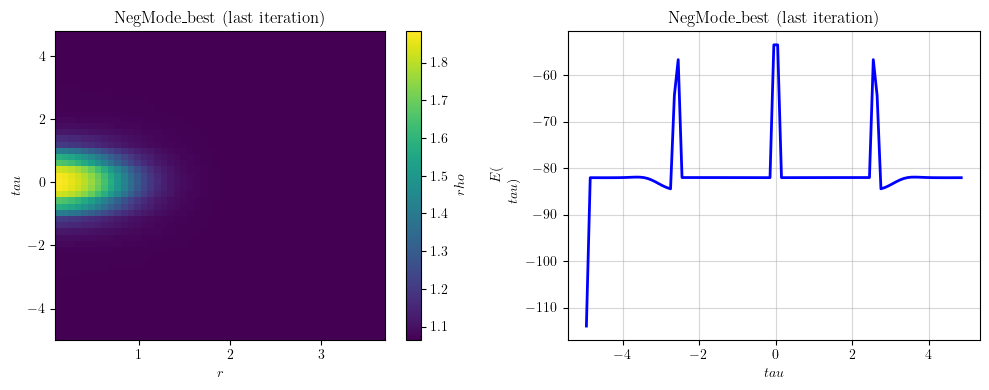

[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01

--- Single-seed: full diagnostics ---
  Seed: NegMode_best,  release_after_pin = True,  eps_pinned = 0.001
  Newton: converged = False,  iterations = 0,  ||F|| = nan
  Homogeneous reference: ω = OMEGA = 0.850000
  Grid: β = 9.8, Lr = 3.7058442697396323, Nr = 50, Nτ = 50
  Volume V = (4/3)π Lr³ = 213.181790
  η₀* = 0.000000

  Solution:
    Q(τ=0) = 206.427472,   E(τ=0) = -84.573372
    ρ_Q = Q/V = 0.968317,   ρ_E = E/V = -0.396719

  Reference homogeneous at ω = OMEGA (same V):
    Q_hom = 205.541665,   E_hom = -80.622836
    ρ_Q,hom = 0.964161,   ρ_E,hom = -0.378188

  Ratios:  Q/Q_hom = 1.004310,  E/E_hom = 1.049000
  Density ratios:  ρ_Q/ρ_Q,hom = 1.004310,  ρ_E/ρ_E,hom = 1.049000
  Difference:  E - E_hom = -3.950536
  E_M - E_M_hom(OMEGA) = 3.950536
  F_ω = -90.889979, 

In [ ]:
# --- Scelta seed e parametri (modifica qui) ---
SEED_TYPE = "NegMode_best"   # "NegMode_best" oppure "NegMode_pinned"
release_after_pin = True     # True/False per find_bounce_from_sphaleron
eps_pinned = 0.001           # usato solo se SEED_TYPE == "NegMode_pinned" (es. 1e-3, 5e-3, 1e-2)

from Bubble_finder.bounce2d import NewtonConvergenceError

eps_list = np.array([1e-2])
best_bounce, diag = find_bounce_from_sphaleron(
    solver, sol_sph,
    eps_list=eps_list, max_tries=10, release_after_pin=release_after_pin, verbose=True,
)
seed_candidates = []
if SEED_TYPE == "NegMode_best":
    if best_bounce is not None:
        seed_candidates = [best_bounce]
elif SEED_TYPE == "NegMode_pinned":
    seed_candidates = [rec["sol"] for rec in diag.get("table", []) if rec.get("sol") is not None]
if not seed_candidates:
    raise RuntimeError(f"No seed found for {SEED_TYPE} with release_after_pin={release_after_pin}, eps_pinned={eps_pinned}")

sol_result = None
for seed_sol in seed_candidates:
    x0_single = solver.pack(seed_sol.y, seed_sol.ybar)
    try:
        sol_result = solver.solve(x0_single, verbose=True, verbose_success_block=True)
        break
    except NewtonConvergenceError as e:
        print(f"NewtonConvergenceError: {e}. Provo il prossimo seed.")
        continue
if sol_result is None:
    print("Attenzione: nessun seed ha convergito. Uso l'ultimo seed per plot e diagnostica.")
    last_seed = seed_candidates[-1]
    _fallback = type('FallbackResult', (), {
        'y': last_seed.y, 'ybar': last_seed.ybar,
        'Q_tau0': getattr(last_seed, 'Q_tau0', 0.0), 'E_tau0': getattr(last_seed, 'E_tau0', 0.0),
        'newton': type('N', (), {'success': False, 'iterations': 0, 'residual_norm': float('nan')})(),
        'observables_ghost': getattr(last_seed, 'observables_ghost', None) or {},
    })()
    sol_result = _fallback

# Plot: ricostruzione completa [-\u03b2/2, \u03b2/2] centrata a \u03c4=0 (richiede cella "Diagnostics helpers")
def _plot_single_seed(sol, title, ax_heat, ax_E):
    try:
        tau_plot, y2, ybar2, _ = recenter_and_centered_tau_plot(sol)
    except NameError:
        raise NameError("Esegui prima la cella 'Diagnostics helpers' che definisce recenter_and_centered_tau_plot.")
    r = np.asarray(solver.grid.r).flatten()
    rho = solver.rho_map(y2, ybar2)
    extent = (r[0], r[-1], tau_plot[0], tau_plot[-1])
    im = ax_heat.imshow(rho.T, origin="lower", aspect="auto", extent=extent)
    ax_heat.set_xlabel(r"$r$")
    ax_heat.set_ylabel(r"$\\tau$")
    ax_heat.set_title(title)
    plt.colorbar(im, ax=ax_heat, label=r"$\\rho$")
    _, E_tau = solver.compute_energy(sol.y, sol.ybar, return_profile=True)
    tau_grid = np.asarray(solver.grid.tau).flatten()
    tau_pos = -np.flip(tau_grid)[1:]
    E_pos = np.flip(E_tau)[1:]
    tau_full = np.concatenate([tau_grid, tau_pos])
    E_full = np.concatenate([E_tau, E_pos])
    sidx = np.argsort(tau_full)
    tau_full, E_full = tau_full[sidx], E_full[sidx]
    ax_E.plot(tau_full, E_full, "b-", lw=2)
    ax_E.set_xlabel(r"$\\tau$")
    ax_E.set_ylabel(r"$E(\\tau)$")
    ax_E.set_title(title)
    ax_E.grid(True, alpha=0.5)

fig_s, axes_s = plt.subplots(1, 2, figsize=(10, 4))
status = "converged" if sol_result.newton.success else "last iteration"
_plot_single_seed(sol_result, f"{SEED_TYPE} ({status})", axes_s[0], axes_s[1])
plt.tight_layout()
fig_s.savefig(FIGURES_DIR / f"single_seed_{SEED_TYPE}.png", dpi=150, bbox_inches="tight")
plt.show()

# Full diagnostics (stesso formato della diagnostica OTHER_ROOT / Final_Bubble_2D)
sol_out = sol_result
r_bb = np.asarray(solver.grid.r).flatten()
Lr_bb = float(r_bb[-1])
V_bb = (4.0 / 3.0) * np.pi * Lr_bb**3
beta_bb = float(getattr(solver.grid, "beta", 2.0 * np.abs(np.ptp(np.asarray(solver.grid.tau).flatten()))))
Nr_bb = len(r_bb)
Ntau_bb = len(np.asarray(solver.grid.tau).flatten())
rho_false_bb, _ = vacua_of_Omega(PHI0, V1, V2, OMEGA)
Q_hom_bb = float(Q_homogeneous_ball(OMEGA, rho_false_bb, Lr_bb))
E_hom_bb = float(homogeneous_energy_2d(OMEGA, rho_false_bb, Lr_bb, U))
Q_sol = float(sol_out.Q_tau0.real)
E_sol = float(sol_out.E_tau0)
rho_Q_hom_bb = Q_hom_bb / V_bb
rho_E_hom_bb = E_hom_bb / V_bb
rho_Q_bb = Q_sol / V_bb
rho_E_bb = E_sol / V_bb
eta_bb = getattr(solver, "eta0", None)
eta_str = f"{eta_bb:.6f}" if eta_bb is not None else "N/A"
print("\n--- Single-seed: full diagnostics ---")
print(f"  Seed: {SEED_TYPE},  release_after_pin = {release_after_pin},  eps_pinned = {eps_pinned}")
print(f"  Newton: converged = {sol_result.newton.success},  iterations = {sol_result.newton.iterations},  ||F|| = {sol_result.newton.residual_norm:.6e}")
print(f"  Homogeneous reference: ω = OMEGA = {OMEGA:.6f}")
print(f"  Grid: β = {beta_bb}, Lr = {Lr_bb}, Nr = {Nr_bb}, Nτ = {Ntau_bb}")
print(f"  Volume V = (4/3)π Lr³ = {V_bb:.6f}")
print(f"  η₀* = {eta_str}")
print("")
print("  Solution:")
print(f"    Q(τ=0) = {Q_sol:.6f},   E(τ=0) = {E_sol:.6f}")
print(f"    ρ_Q = Q/V = {rho_Q_bb:.6f},   ρ_E = E/V = {rho_E_bb:.6f}")
print("")
print("  Reference homogeneous at ω = OMEGA (same V):")
print(f"    Q_hom = {Q_hom_bb:.6f},   E_hom = {E_hom_bb:.6f}")
print(f"    ρ_Q,hom = {rho_Q_hom_bb:.6f},   ρ_E,hom = {rho_E_hom_bb:.6f}")
print("")
print(f"  Ratios:  Q/Q_hom = {Q_sol/Q_hom_bb:.6f},  E/E_hom = {E_sol/E_hom_bb:.6f}")
print(f"  Density ratios:  ρ_Q/ρ_Q,hom = {rho_Q_bb/rho_Q_hom_bb:.6f},  ρ_E/ρ_E,hom = {rho_E_bb/rho_E_hom_bb:.6f}")
print(f"  Difference:  E - E_hom = {E_sol - E_hom_bb:.6f}")
obs_bb = getattr(sol_out, "observables_ghost", None) or {}
E_M_hom_bb = float(homogeneous_E_M_2d(OMEGA, rho_false_bb, Lr_bb, U))
if "E_M" in obs_bb:
    print(f"  E_M - E_M_hom(OMEGA) = {obs_bb['E_M'] - E_M_hom_bb:.6f}")
if "F_omega" in obs_bb:
    F_bb = obs_bb["F_omega"]
    F_hom_bb = E_M_hom_bb - OMEGA * Q_hom_bb
    print(f"  F_ω = {F_bb:.6f},  F_ω,hom = {F_hom_bb:.6f},  F_ω - F_ω,hom = {F_bb - F_hom_bb:.6f}")
print("---")

## 8. Takeaways

- **Which seed families tend to land on sphaleron?** (Summarise from the DataFrame: e.g. O3_gated with certain tau_gate_center_frac/amp, Sph_pert.)
- **Which escape to other roots?** (e.g. TauFourier, NegMode_pinned with release_after_pin=True.)
- **Which parameters matter most?** (tau centering, ramp on/off, amplitude — note: ramp is fixed in the library for build_seed_bubble.)

In [12]:
counts = df["label"].value_counts()
print("Counts by label:", counts.to_dict())
print("\nSeeds converging to SPHALERON (first 5):")
print(df[df["label"] == "SPHALERON"][["name", "dist_sph", "amp_tau"]].head())
print("\nSeeds converging to BANAL (first 5):")
print(df[df["label"] == "BANAL"][["name", "dist_banal", "amp_tau"]].head())
print("\nSeeds converging to OTHER_ROOT (first 5):")
print(df[df["label"] == "OTHER_ROOT"][["name", "dist_sph", "dist_banal", "amp_tau"]].head())

Counts by label: {'BANAL': 9, 'SPHALERON': 4, 'OTHER_ROOT': 3, 'DIVERGED': 2}

Seeds converging to SPHALERON (first 5):
              name      dist_sph   amp_tau
14  NegMode_pinned  4.561859e-08  0.815392
15  NegMode_pinned  4.562277e-08  0.815392
16  NegMode_pinned  1.208474e-07  0.815392
17  NegMode_pinned  1.208478e-07  0.815392

Seeds converging to BANAL (first 5):
         name    dist_banal       amp_tau
0  TauFourier  1.652292e-14  2.220446e-16
1  TauFourier  1.576641e-14  2.220446e-16
2  TauFourier  1.652693e-14  2.220446e-16
3  TauFourier  1.995458e-14  1.554312e-15
4  TauFourier  1.754997e-14  2.220446e-16

Seeds converging to OTHER_ROOT (first 5):
        name  dist_sph  dist_banal   amp_tau
11  Sph_pert  0.009190    7.749280  0.815392
12  Sph_pert  0.010363    7.749282  0.815392
13  Sph_pert  0.043002    7.749394  0.815392
